In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings("ignore")

The goal of this notebook is to use the revenue and value function provided by Legros et al. in the paper *Should We Wait Before Outsourcing? Analysis of a Revenue-Generating Blended Contact Center*

They modelled revenue $E(G)$ as a function of two type of calls. Class-1 refers to calls about inbound problems and Class-2 refers to outbound calls. Specifically, if a customer comes to the call center with a problem, then it is an inbound Class-1 call. However, if the call center agent had to call the customers, then it would be Class-2. The authors also modelled outsourcing as a form of cost saving. The call center has a contract with another company where the can allocate $P_{\bar{S}} \in (0, 1)$ of their inbound calls to that other company. 

To model revenue, they treat each class separately. The revenue for inbound Class-1 calls is a product of revenue per call $r_1$, arrival rate $\lambda$, number of calls taken in-house $(1 - P_{\bar{S}})$, and waiting time $E(W_s)$. The revenue for outbound Class-2 calls is treated more simply with revenue per call $r_2$ and throughput $T$. We finally just have the expense from the other company of $C_\text{outs}$. Overall, the revenue is
$$E(G) = r_2E(T) + r_1 \lambda (1 - P_{\bar{S}})(1 - \omega E(W_S)) - C_{\text{outs}}$$


For the value funciton, I would be focusing on the a posteriori policies where inbound calls are outsourced after some period of time. 
For clarity, our state space is $[-s, \infty)$ where if $x \in [-s, 0]$, it means how many free live agents are there. For example, if $s=4$ and $x=-3$, then it means there are three free servers and one busy server. Hence, $s+x$ agents are busy and thus helping out in the service rate $\mu$. For $x > 0$, we actually discretized the FIL waiting time into smaller chunks. Because we now have many small chunks, we would aggregate over this by having an operator $F$ on the set of functions $f:\mathbb{Z} \to \mathbb{R}$ defined by $F(f(x)) = \sum_{h=0}^x q_{x, x-h} f(x-h)$ for $x > 0$ and $F(f(x)) = f(x)$ for $x \leq 0$. "This operator is used to simplify the notations. It represents the possible changes in the state of the FIL when eitther an outsourcing or a service completion occurs"
This was done to approximate the continuous-time markov chain. However, this just makes the math a bit harder. 

For the value function $V_k(x)$, we consider $U_k(x)$ and $W_k(x)$. The former tells us about decisions on outsourcing or not. Later on, there will be the $\max$ operator to show that $U_k(x)$ will determine if it is more beneficial to outsource or just let the new customer enter the queue. For the latter, $W_k(x)$ representes the alue after making a service decision for Class-2 calls. There will also be the $\max$ operator to show a decision if it is better to take on an outbound call or just wait.


Finally, $k$ here just acts as a way to index the bellman backup. We are just going to reiteratively loop until $V$ converges. 
Anyways, there are two cases to consider:
* Case 1 - When $x \in [-s, 0]$:
$$V_{k+1} = \lambda U_k(x) + (s+x) \mu W_{k+1}(x-1) + \big(1 - \lambda - (s + x) \mu \big) W_k(x), $$
where
\begin{align*}
U_k(x) &= V_k(x+1) + r_1, \\  
W_k(x) &= \max \big\{V_k(x), V_k(x+1) + r_2 \big\}.
\end{align*}
* Case 2 - When $x \in (0, \infty)$:
$$V_{k+1}(x) = \gamma U_k(x) + s \mu \big( F(W_k(x)) + r_1 (1 - \omega \frac{x}{\gamma}) \big) + (1 - \gamma - s \mu) W_k(x),$$
where
\begin{align*}
U_k(x) &= \max \big\{F(V_k(x)) - L, V_k(x+1) \big\}, \\  
W_k(x) &= V_k(x).
\end{align*}

In [42]:
class TwoClassQueueMDP:
    def __init__(self,
                 lam=0.30, s=2, mu=0.35, gamma=0.20,
                 r1=5.0, r2=3.0, L=2.0, omega=0.30,
                 X_MAX=15, EPS=1e-4, MAX_ITER=500):

        # Parameters
        self.lam = lam
        self.s = s
        self.mu = mu
        self.gamma = gamma
        self.r1 = r1
        self.r2 = r2
        self.L = L
        self.omega = omega

        self.X_MAX = X_MAX
        self.EPS = EPS
        self.MAX_ITER = MAX_ITER

        # State space
        self.states = list(range(-s, X_MAX + 1))
        self.N = len(self.states)

        # Convergence logs
        self.Ve, self.Vl = None, None
        self.conv_e, self.conv_l = None, None
        self.snaps_e, self.snaps_l = None, None

    # ─────────────────────────────────────────────
    # State utilities
    # ─────────────────────────────────────────────
    def idx(self, x):
        return x + self.s

    # ════════════════════════════════════════════
    # a priori operators
    # ════════════════════════════════════════════
    def _U_e(self, x, V):
        i = self.idx(x)
        if x < 0:
            return V[i] + self.r1
        v_queue = V[i + 1] if i + 1 < self.N else V[i]
        v_out = V[i] - self.L
        return max(v_queue, v_out)

    def _W_e(self, x, V):
        i = self.idx(x)
        if x < 0:
            v_idle = V[i]
            v_init = (V[i + 1] if i + 1 < self.N else V[i]) + self.r2
            return max(v_idle, v_init)
        return V[i]

    def _bellman_e(self, V):
        scale = self.lam + self.s * self.mu
        lam = self.lam / scale
        mu = self.mu / scale

        Vn = np.zeros(self.N)

        for i, x in enumerate(self.states):
            busy = min(self.s, self.s + x)
            mu_eff = busy * mu

            Ux = self._U_e(x, V)

            W_prev = self._W_e(x - 1, V) if x - 1 >= -self.s else 0.0
            Wx = self._W_e(x, V)

            r1_adj = self.r1 * (1 - self.omega * x / (self.s * mu)) if x > 0 else 0.0

            Vn[i] = lam * Ux + mu_eff * (W_prev + r1_adj) + (1 - lam - mu_eff) * Wx

        return Vn

    # ════════════════════════════════════════════
    # a posteriori operators
    # ════════════════════════════════════════════
    def _F(self, x, V):
        if x <= 0:
            return V[self.idx(x)]
        j = self.idx(x - 1)
        return V[j] if j >= 0 else V[self.idx(x)]

    def _U_l(self, x, V):
        FV = self._F(x, V)
        keep = V[self.idx(x) + 1] if self.idx(x) + 1 < self.N else V[self.idx(x)]
        return max(keep, FV - self.L)

    def _W_l(self, x, V):
        i = self.idx(x)
        if x < 0:
            return max(V[i], (V[i + 1] if i + 1 < self.N else V[i]) + self.r2)
        return V[i]

    def _bellman_l(self, V):
        scale = self.lam + self.s * self.mu + self.gamma
        lam = self.lam / scale
        mu = self.mu / scale
        gam = self.gamma / scale

        Vn = np.zeros(self.N)

        for i, x in enumerate(self.states):
            if x <= 0:
                Ux = V[i] + self.r1 if x < 0 else self._U_l(x, V)
                mu_eff = (self.s + x) * mu

                W_prev = self._W_l(x - 1, V) if x - 1 >= -self.s else 0.0
                Wx = self._W_l(x, V)

                Vn[i] = lam * Ux + mu_eff * W_prev + (1 - lam - mu_eff) * Wx

            else:
                Ux = self._U_l(x, V)
                Fx = self._F(x, V)
                Wx = self._W_l(x, V)

                r1_adj = self.r1 * (1 - self.omega * x / max(gam, 1e-9))

                Vn[i] = gam * Ux + self.s * mu * (Fx + r1_adj) + (1 - gam - self.s * mu) * Wx

        return Vn

    # ════════════════════════════════════════════
    # Value iteration
    # ════════════════════════════════════════════
    def solve_e(self):
        V = np.zeros(self.N)
        conv, snaps = [], {}

        for k in range(self.MAX_ITER):
            if k in {0, 5, 20, 100, 250, 350, 450}:
                snaps[k] = V.copy()

            Vn = self._bellman_e(V)
            delta = np.max(np.abs(Vn - V))
            conv.append(delta)
            V = Vn

            if delta < self.EPS:
                break

        snaps["final"] = V.copy()
        self.Ve, self.conv_e, self.snaps_e = V, conv, snaps
        return V

    def solve_l(self):
        V = np.zeros(self.N)
        conv, snaps = [], {}

        for k in range(self.MAX_ITER):
            if k in {0, 5, 20, 100, 250, 350, 450}:
                snaps[k] = V.copy()

            Vn = self._bellman_l(V)
            delta = np.max(np.abs(Vn - V))
            conv.append(delta)
            V = Vn

            if delta < self.EPS:
                break

        snaps["final"] = V.copy()
        self.Vl, self.conv_l, self.snaps_l = V, conv, snaps
        return V

    # ════════════════════════════════════════════
    # Policy extraction
    # ════════════════════════════════════════════
    def extract_policy_e(self, V):
        policy = {}
        for i, x in enumerate(self.states):
            if x < 0:
                policy[x] = {
                    "class1": "accept",
                    "class2": "initiate" if self._W_e(x, V) >= V[i] else "idle"
                }
            else:
                vq = V[i + 1] if i + 1 < self.N else V[i]
                policy[x] = {
                    "class1": "queue" if vq >= V[i] - self.L else "outsource",
                    "class2": "N/A"
                }
        return policy

    def extract_policy_l(self, V):
        policy = {}
        for i, x in enumerate(self.states):
            if x < 0:
                policy[x] = {"class1": "accept"}
            elif x == 0:
                policy[x] = {"class1": "keep" if V[i + 1] >= V[i] - self.L else "outsource"}
            else:
                policy[x] = {
                    "class1": "keep" if self._F(x, V) >= V[i] - self.L else "outsource"
                }
        return policy

    # ════════════════════════════════════════════
    # Plotting
    # ════════════════════════════════════════════
    def plot(self):
        if self.Ve is None or self.Vl is None:
            raise ValueError("Run solve_e() and solve_l() first.")

        #plt.style.use("seaborn-v0_8-whitegrid")

        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        x = np.array(self.states)

        # ─────────────────────────────
        # Convergence Ω_e
        # ─────────────────────────────
        ax = axes[0, 0]
        ax.plot(self.conv_e, linewidth=1.8)
        ax.set_title("Convergence for a Priori Policies", fontsize=11)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("max |ΔV|")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

        # ─────────────────────────────
        # Convergence Ω_l
        # ─────────────────────────────
        ax = axes[0, 1]
        ax.plot(self.conv_l, linewidth=1.8)
        ax.set_title("Convergence for a Posteriori Policies", fontsize=11)
        ax.set_xlabel("Iteration")
        ax.set_ylabel("max |ΔV|")
        ax.set_yscale("log")
        ax.grid(True, alpha=0.3)

        # ─────────────────────────────
        # Value function Ω_e
        # ─────────────────────────────
        ax = axes[1, 0]
        for k, v in sorted(self.snaps_e.items(), key=lambda t: str(t[0])):
            ax.plot(x, v, alpha=0.7 if k != "final" else 1.0,
                    linewidth=2.2 if k == "final" else 1.0,
                    label=f"k={k}")

        ax.set_title("Value Across States for a Priori Policies Until Convergence", fontsize=11)
        ax.set_xlabel("State x")
        ax.set_ylabel("V(x)")
        ax.axvline(0, linestyle="--", linewidth=1, alpha=0.5)
        ax.legend(fontsize=8, ncol=2, frameon=True)
        ax.grid(True, alpha=0.3)

        # ─────────────────────────────
        # Value function Ω_l
        # ─────────────────────────────
        ax = axes[1, 1]
        for k, v in sorted(self.snaps_l.items(), key=lambda t: str(t[0])):
            ax.plot(x, v, alpha=0.7 if k != "final" else 1.0,
                    linewidth=2.2 if k == "final" else 1.0,
                    label=f"k={k}")

        ax.set_title("Value Across States for a Posteriori Policies Until Convergence", fontsize=11)
        ax.set_xlabel("State x")
        ax.set_ylabel("V(x)")
        ax.axvline(0, linestyle="--", linewidth=1, alpha=0.5)
        ax.legend(fontsize=8, ncol=2, frameon=True)
        ax.grid(True, alpha=0.3)

        fig.suptitle(
            "Two-Class Queueing MDP with Outsourcing",
            fontsize=13,
            y=1.02
        )
        plt.tight_layout()

        plt.show()

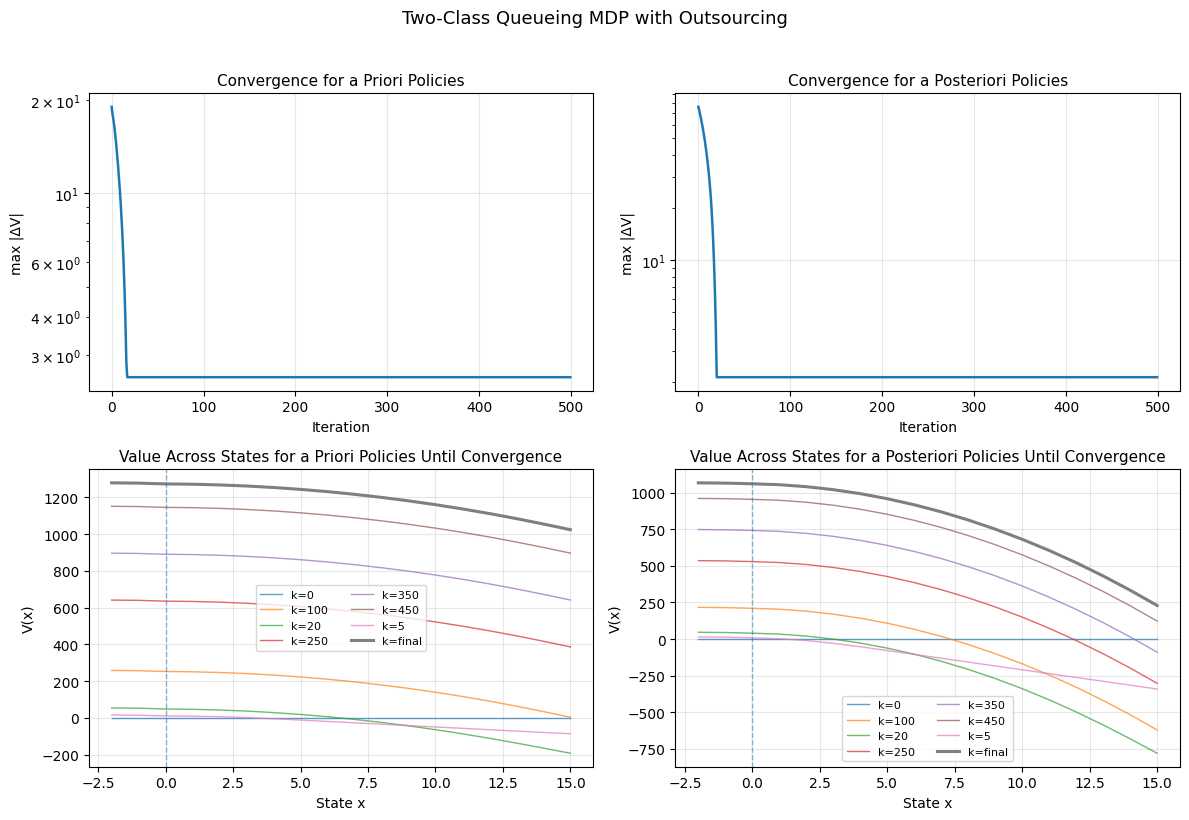

In [43]:
mdp = TwoClassQueueMDP()

mdp.solve_e()
mdp.solve_l()

policy_e = mdp.extract_policy_e(mdp.Ve)
policy_l = mdp.extract_policy_l(mdp.Vl)

mdp.plot()

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings("ignore")


class RoutingSensitivityAnalysis:
    """
    Sensitivity analysis of routing thresholds x*
    under two policies:

        Ω_e : a priori (arrival-time decision)
        Ω_l : a posteriori (FIL decision)

    Outputs:
        - pandas tables of thresholds
        - optional heatmap-style plot
    """

    # ─────────────────────────────────────────────
    # Initialization
    # ─────────────────────────────────────────────
    def __init__(
        self,
        lam=0.30, s=2, mu=0.35,
        gamma=0.20, L=2.0, omega=0.30,
        X_MAX=12, EPS=1e-3, MAX_ITER=300,
        r1_vals=None, r2_vals=None
    ):
        self.lam = lam
        self.s = s
        self.mu = mu
        self.gamma = gamma
        self.L = L
        self.omega = omega

        self.X_MAX = X_MAX
        self.EPS = EPS
        self.MAX_ITER = MAX_ITER

        self.R1 = r1_vals or [1,2,3,4,5,6,7,8,9,10]
        self.R2 = r2_vals or [10,8,6,4,2,1]

        self.results_e = {}
        self.results_l = {}

    # ═════════════════════════════════════════════
    # Ω_e : A PRIORI VALUE ITERATION
    # ═════════════════════════════════════════════
    def solve_omega_e(self, r1, r2):

        states = list(range(-self.s, self.X_MAX + 1))
        N = len(states)

        scale = self.lam + self.s * self.mu
        le, me = self.lam / scale, self.mu / scale

        V = np.zeros(N)

        for _ in range(self.MAX_ITER):
            Vn = np.zeros(N)

            for i, x in enumerate(states):
                busy = min(self.s, self.s + x)
                mu_eff = busy * me

                # class-1 decision
                if x < 0:
                    Uk = V[i] + r1
                else:
                    vq = V[min(i + 1, N - 1)]
                    Uk = max(vq, V[i] - self.L)

                # class-2 backward influence
                if x - 1 >= -self.s:
                    j = i - 1
                    if states[j] < 0:
                        W_prev = max(V[j], V[min(j+1, N-1)] + r2)
                    else:
                        W_prev = V[j]
                else:
                    W_prev = 0.0

                r1_adj = r1 * (1 - self.omega * x / (self.s * me)) if x > 0 else 0

                W = V[i] if x >= 0 else max(V[i], V[min(i+1, N-1)] + r2)

                Vn[i] = le * Uk + mu_eff * (W_prev + r1_adj) + (1 - le - mu_eff) * W

            if np.max(np.abs(Vn - V)) < self.EPS:
                break
            V = Vn

        return self._policy(V, states)

    # ═════════════════════════════════════════════
    # Ω_l : A POSTERIORI VALUE ITERATION
    # ═════════════════════════════════════════════
    def solve_omega_l(self, r1, r2):

        states = list(range(-self.s, self.X_MAX + 1))
        N = len(states)

        scale = self.lam + self.s * self.mu + self.gamma
        ll, ml, gl = self.lam/scale, self.mu/scale, self.gamma/scale

        V = np.zeros(N)

        for _ in range(self.MAX_ITER):
            Vn = np.zeros(N)

            for i, x in enumerate(states):

                FV = self._F(x, V)

                if x <= 0:
                    Uk = V[i] + r1 if x < 0 else max(V[min(i+1,N-1)], V[i] - self.L)
                    mu_eff = (self.s + x) * ml

                    W = V[i] if x >= 0 else max(V[i], V[min(i+1,N-1)] + r2)

                    Vn[i] = ll * Uk + mu_eff * FV + (1 - ll - mu_eff) * W

                else:
                    vq = V[min(i+1, N-1)]
                    Uk = max(vq, FV - self.L)

                    r1_adj = r1 * (1 - self.omega * x / max(gl, 1e-9))

                    Vn[i] = gl * Uk + self.s * ml * (FV + r1_adj) + (1 - gl - self.s * ml) * V[i]

            if np.max(np.abs(Vn - V)) < self.EPS:
                break
            V = Vn

        return self._policy(V, states)

    # ═════════════════════════════════════════════
    # FIL OPERATOR
    # ═════════════════════════════════════════════
    def _F(self, x, V):
        xi = x + self.s
        return V[xi] if x <= 0 else V[max(xi - 1, 0)]

    # ═════════════════════════════════════════════
    # POLICY EXTRACTION
    # ═════════════════════════════════════════════
    def _policy(self, V, states):

        policy = {}

        for i, x in enumerate(states):

            if x < 0:
                policy[x] = "accept"

            elif x == 0:
                vq = V[min(i+1, len(states)-1)]
                policy[x] = "accept" if vq >= V[i] - self.L else "outsource"

            else:
                FV = self._F(x, V)
                vq = V[min(i+1, len(states)-1)]
                policy[x] = "accept" if vq >= FV - self.L else "outsource"

        thresh = next((x for x in range(self.X_MAX + 1)
                       if policy.get(x) == "outsource"), None)

        return policy, thresh

    # ═════════════════════════════════════════════
    # RUN SWEEP
    # ═════════════════════════════════════════════
    def run(self):

        for r2 in self.R2:
            self.results_e[r2] = {}
            self.results_l[r2] = {}

            for r1 in self.R1:
                _, te = self.solve_omega_e(r1, r2)
                _, tl = self.solve_omega_l(r1, r2)

                self.results_e[r2][r1] = te
                self.results_l[r2][r1] = tl

    # ═════════════════════════════════════════════
    # PANDAS TABLE OUTPUT
    # ═════════════════════════════════════════════
    def to_dataframe(self, which="e"):

        results = self.results_e if which == "e" else self.results_l

        df = pd.DataFrame(index=self.R2, columns=self.R1)

        for r2 in self.R2:
            for r1 in self.R1:
                t = results[r2][r1]

                if t is None:
                    df.loc[r2, r1] = "human agent"
                elif t == 0:
                    df.loc[r2, r1] = "give chatbot"
                else:
                    df.loc[r2, r1] = f"x<{t} accept, otherwise outsource"

        df.index.name = "r2 \\ r1"
        return df

    # ═════════════════════════════════════════════
    # OPTIONAL PLOT
    # ═════════════════════════════════════════════
    def plot(self):

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        for ax, results, title in zip(
            axes,
            [self.results_e, self.results_l],
            ["Ω_e (a priori)", "Ω_l (a posteriori)"]
        ):
            ax.set_title(title)

            for j, r2 in enumerate(reversed(self.R2)):
                for i, r1 in enumerate(self.R1):

                    t = results[r2][r1]
                    color = "#C0DD97" if t is None else "#FCEBEB" if t == 0 else "#FAEEDA"

                    ax.add_patch(
                        mpatches.FancyBboxPatch(
                            (i, j), 1, 1,
                            facecolor=color,
                            edgecolor="white"
                        )
                    )

                    label = "A" if t is None else "O" if t == 0 else f"{t}"
                    ax.text(i+0.5, j+0.5, label,
                            ha="center", va="center", fontsize=9)

            ax.set_xticks([i+0.5 for i in range(len(self.R1))])
            ax.set_xticklabels(self.R1)

            ax.set_yticks([j+0.5 for j in range(len(self.R2))])
            ax.set_yticklabels(list(reversed(self.R2)))

            ax.tick_params(length=0)

        plt.tight_layout()
        plt.show()

In [69]:
exp = RoutingSensitivityAnalysis()
exp.run()

df_e = exp.to_dataframe("e")
df_l = exp.to_dataframe("l")

print("columnsare for r1 (agent), rows are for r2 (chatbot)")
print("A priori")
display(df_e[::-1])
print()
print("A posteriori")
display(df_l[::-1])

columnsare for r1 (agent), rows are for r2 (chatbot)
A priori


,1,2,3,4,5,6,7,8,9,10
r2 \ r1,,,,,,,,,,
1,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource"
2,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource"
4,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource"
6,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot
8,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot
10,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot



A posteriori


,1,2,3,4,5,6,7,8,9,10
r2 \ r1,,,,,,,,,,
1,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource",give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot
2,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource",give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot
4,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource",give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot
6,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource",give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot
8,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource",give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot
10,"x<1 accept, otherwise outsource","x<1 accept, otherwise outsource","x<1 accept, otherwise outsource",give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot,give chatbot


if the chatbot is free, how many do you need to serve before it pays for itself. 

just find the break even point. For optimal happiness of the customers, assuming the wait time. reverse engineer to find the fair price of LLM. Given the cost of LLMs, what is the fair price of human labor?

what is the cost of humans (from glassdoor) and then find the fair cost of LLM?

What is the equivalent price of a chatbot in terms of services it provides. Is the cost of actually buying it less than that? This is the optimal performance of this set of stats for the LLM with some sort of throughput. What was the break even point for that performance so that would tell you of the fair price of the LLM. 

I would also need to think about the fix and maintenance cost before the LLM pays for itself.  

banana farm bloons tower defense

https://www.youtube.com/watch?v=DsH0NZQsRbU&t=1028s

there is an upfront cost so it takes longer for it improve on.

since we are talking about revenue so we need to talk about costs (upfront maintenance and such). The upfront is more important because if capital is low, then we cant do that. We assume capital is high, and we bruteforce optimize what is the most efficiet or highest ROI. 

now, we need to think on the actual running costs. 

We assume for now that initial capital is high. We look into the optimize throughput of customers. We would want to do this to justify a stakeholder that if the customer maintenance cost (is some money), then we will make this much more money. 

If this throughput is to just break even, what is the actual value of LLM. 

the maintenance cost and server cost is competing agianst humans who have their own price. If the LLM is as good as a human, the LLM is providing 

1) if i optimize for cost versus optimize for throughput, would they be different?
2) find E(G), whatever value you assign to serve the customer. 
maybe check here for the value protection. over the lifetime of a customer, theyre spending habits would probably be a straight line. so at what point would they leave? probably at the halfway point. you could model a spending habits of the customer based on some distribution. If you resolve the issue, they wont leave the market. You are protecting the lifetime value.
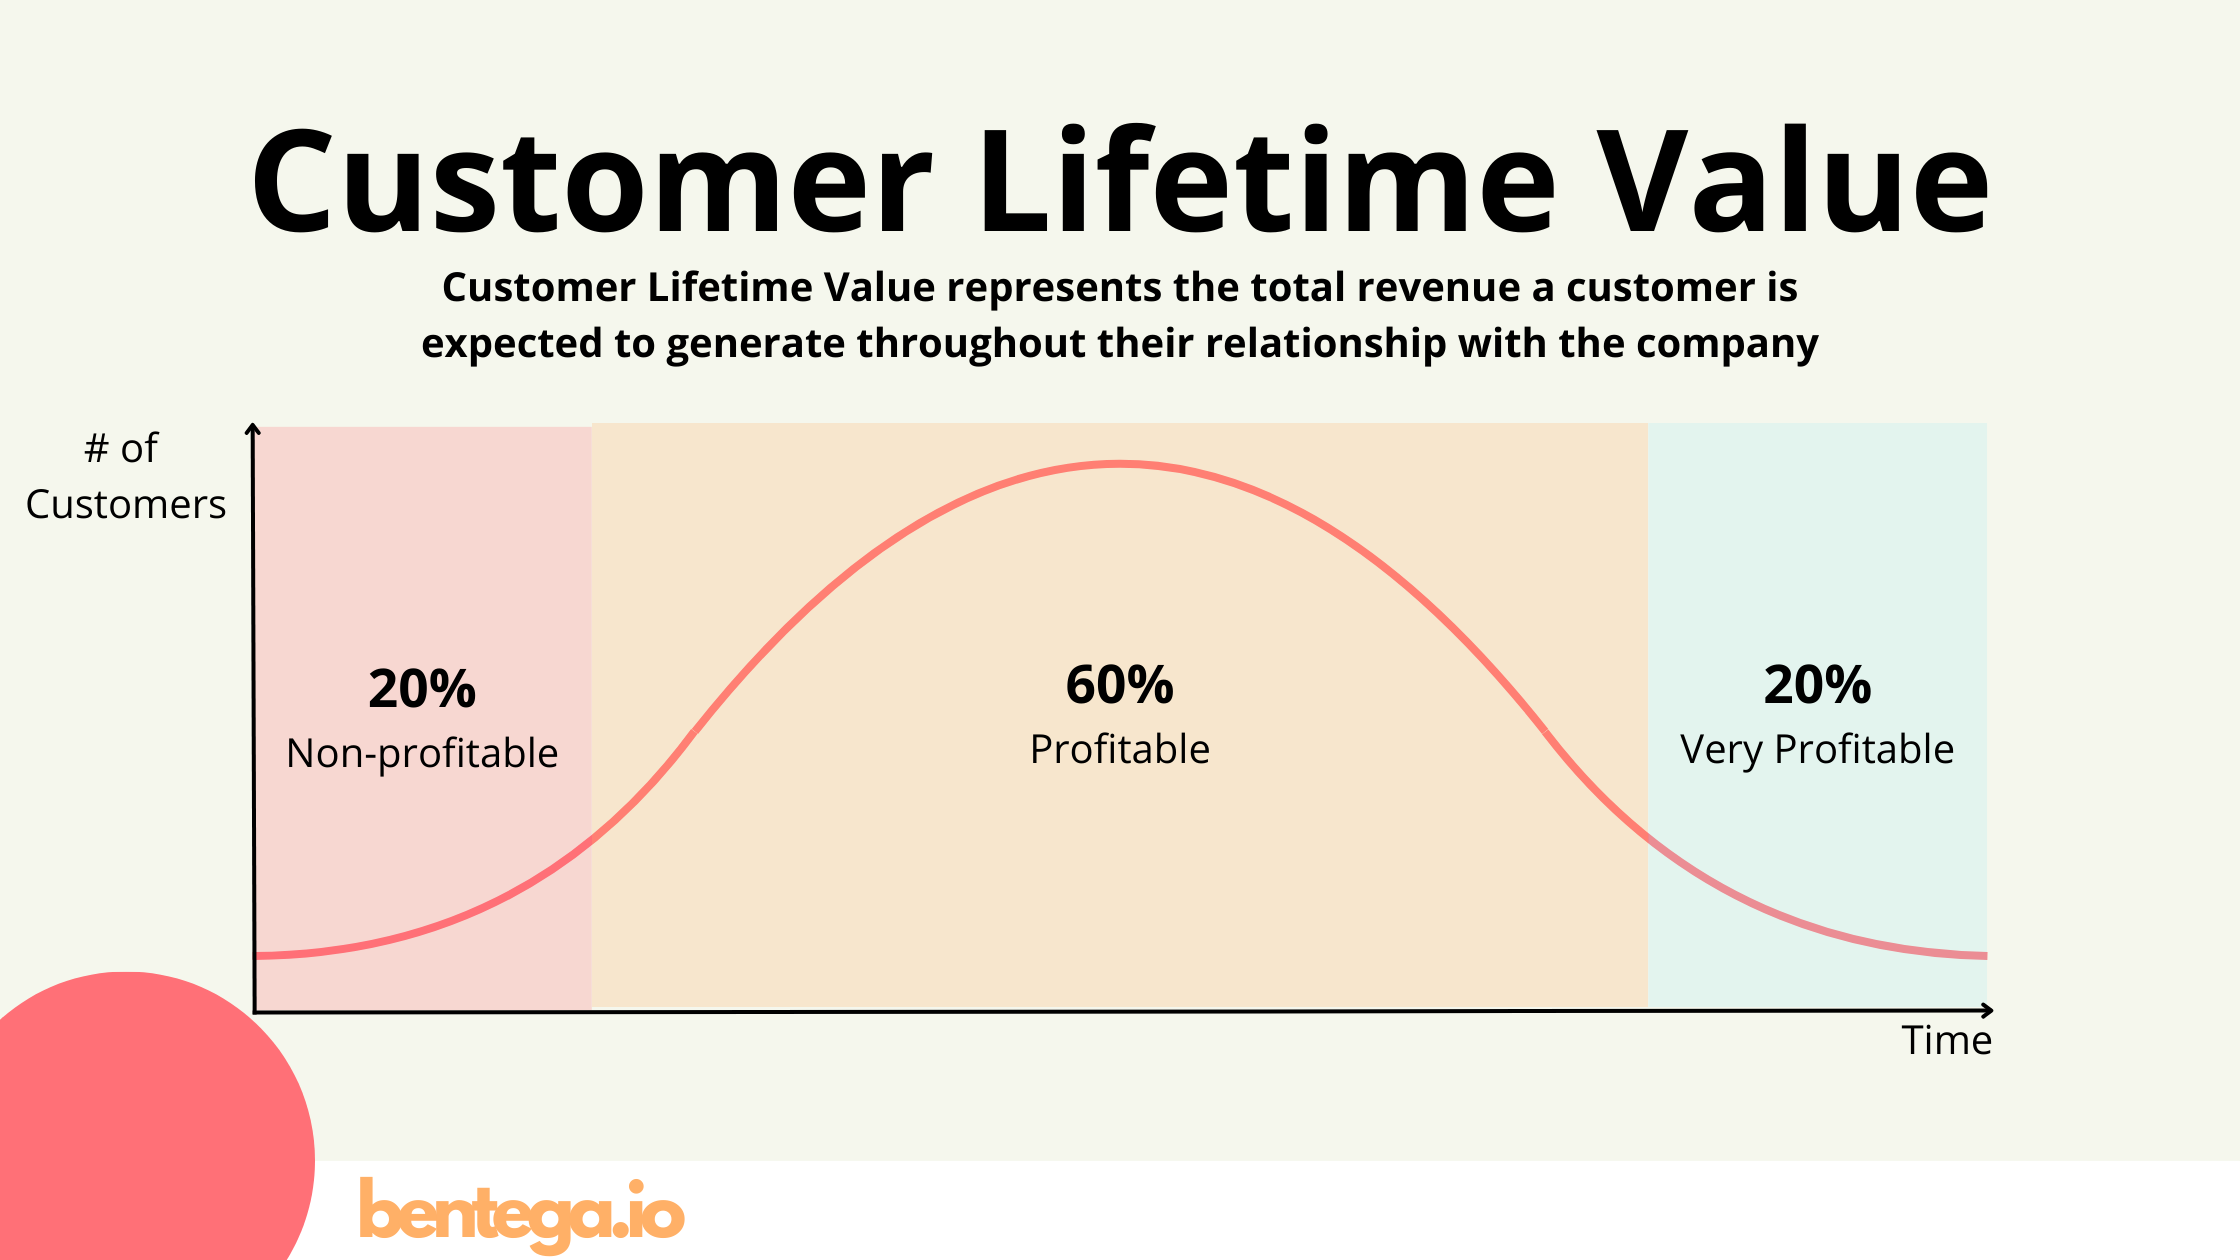